# BankSight: Synthetic Banking Data Analysis
### Customer, Account, Transaction & Risk Analytics

**Author:** [Your Name] | **Role target:** Data Analyst / BI Co-op | **Date:** September 2026

---
## Project Overview
This project analyzes a synthetic banking dataset covering 50,000 customers, 75,000 accounts, 100,000 cards, 30,000 loans, 5,000 merchants, and 1,000,000 transactions (2019–2025). The dataset is relational (SQLite), so this project demonstrates **SQL querying combined with Python analysis**.

**Business questions answered:**
1. Is the data clean and internally consistent?
2. How is customer growth and account balance distributed?
3. What do monthly transaction patterns look like?
4. Does credit score predict loan interest rate?
5. Can we segment customers into risk/value tiers?
6. Can we flag statistically unusual transactions?

**Tools:** Python (pandas, sqlite3, matplotlib, seaborn) + SQL (SQLite)

In [17]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

BASE = "../data/raw/banking_dataset_kaggle/data"
con = sqlite3.connect(f"{BASE}/database/bank_sqlite.db")

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)
print("Tables:", tables['name'].tolist())

Tables: ['accounts', 'branches', 'cards', 'customers', 'loans', 'merchants', 'transactions']


## 1. Data Quality & Referential Integrity

Since this is relational data, the first check isn't just nulls/duplicates — it's whether foreign keys actually resolve (e.g. does every transaction point to a real account?).

In [18]:
customers = pd.read_sql("SELECT * FROM customers", con)
accounts = pd.read_sql("SELECT * FROM accounts", con)
cards = pd.read_sql("SELECT * FROM cards", con)
loans = pd.read_sql("SELECT * FROM loans", con)
merchants = pd.read_sql("SELECT * FROM merchants", con)
transactions = pd.read_sql("SELECT * FROM transactions", con)

tables_dict = {"customers": customers, "accounts": accounts, "cards": cards,
               "loans": loans, "merchants": merchants, "transactions": transactions}

for name, df in tables_dict.items():
    print(f"{name}: {df.shape[0]:,} rows, {df.isna().sum().sum()} nulls, {df.duplicated().sum()} dupes")

customers: 50,000 rows, 0 nulls, 0 dupes
accounts: 75,000 rows, 0 nulls, 0 dupes
cards: 100,000 rows, 0 nulls, 0 dupes
loans: 30,000 rows, 0 nulls, 0 dupes
merchants: 5,000 rows, 0 nulls, 0 dupes
transactions: 1,000,000 rows, 0 nulls, 0 dupes


In [19]:
orphan_accounts = (~accounts['customer_id'].isin(customers['customer_id'])).sum()
orphan_cards = (~cards['account_id'].isin(accounts['account_id'])).sum()
orphan_loans = (~loans['customer_id'].isin(customers['customer_id'])).sum()
orphan_txn_acct = (~transactions['account_id'].isin(accounts['account_id'])).sum()
orphan_txn_merch = (~transactions['merchant_id'].isin(merchants['merchant_id'])).sum()

print(f"Orphaned accounts: {orphan_accounts}")
print(f"Orphaned cards: {orphan_cards}")
print(f"Orphaned loans: {orphan_loans}")
print(f"Orphaned transactions (account): {orphan_txn_acct}")
print(f"Orphaned transactions (merchant): {orphan_txn_merch}")

Orphaned accounts: 0
Orphaned cards: 0
Orphaned loans: 0
Orphaned transactions (account): 0
Orphaned transactions (merchant): 0


**Finding:** Zero nulls, zero duplicates, zero broken foreign keys across every table. This is unusually clean — typical of a synthetic dataset rather than production data, where you'd expect at least some data entry errors or timing-related orphan records.

## 2. Customer & Account Overview

,account_type,num_accounts,avg_balance,total_balance
0,Checking,25080,"100,097.20","2,510,437,746.15"
1,Savings,25102,"99,963.17","2,509,275,452.08"
2,Business,24818,"99,702.86","2,474,425,544.54"


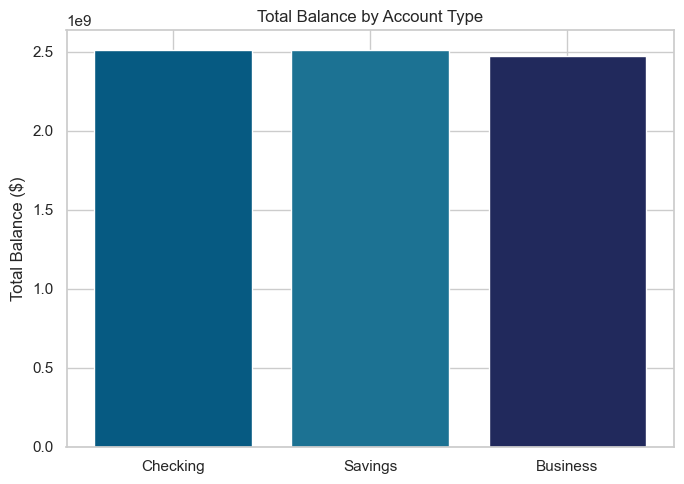

In [20]:
balance_by_type = pd.read_sql(
    "SELECT account_type, COUNT(*) AS num_accounts, "
    "ROUND(AVG(balance_usd),2) AS avg_balance, ROUND(SUM(balance_usd),2) AS total_balance "
    "FROM accounts GROUP BY account_type ORDER BY total_balance DESC", con)
display(balance_by_type)

fig, ax = plt.subplots(figsize=(7,5))
ax.bar(balance_by_type['account_type'], balance_by_type['total_balance'], color=["#065A82","#1C7293","#21295C"])
ax.set_title('Total Balance by Account Type')
ax.set_ylabel('Total Balance ($)')
plt.tight_layout()
plt.show()

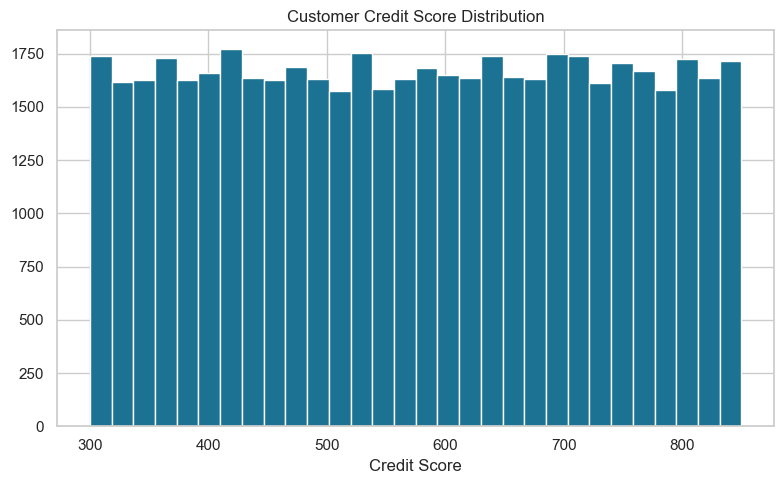

count   50,000.00
mean       575.10
std        159.10
min        300.00
25%        437.00
50%        576.00
75%        713.00
max        850.00
Name: credit_score, dtype: float64


In [21]:
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(customers['credit_score'], bins=30, color='#1C7293', edgecolor='white')
ax.set_title('Customer Credit Score Distribution')
ax.set_xlabel('Credit Score')
plt.tight_layout()
plt.show()

print(customers['credit_score'].describe().round(1))

**Finding:** Checking, Savings, and Business accounts hold nearly identical total balances (~$2.5B each) — account type doesn't meaningfully differentiate value here. Credit scores span the full 300–850 range in a uniform (flat) distribution, unlike real-world populations which cluster in the 650–750 band. This flat distribution matters for later sections.

## 3. Transaction Trends

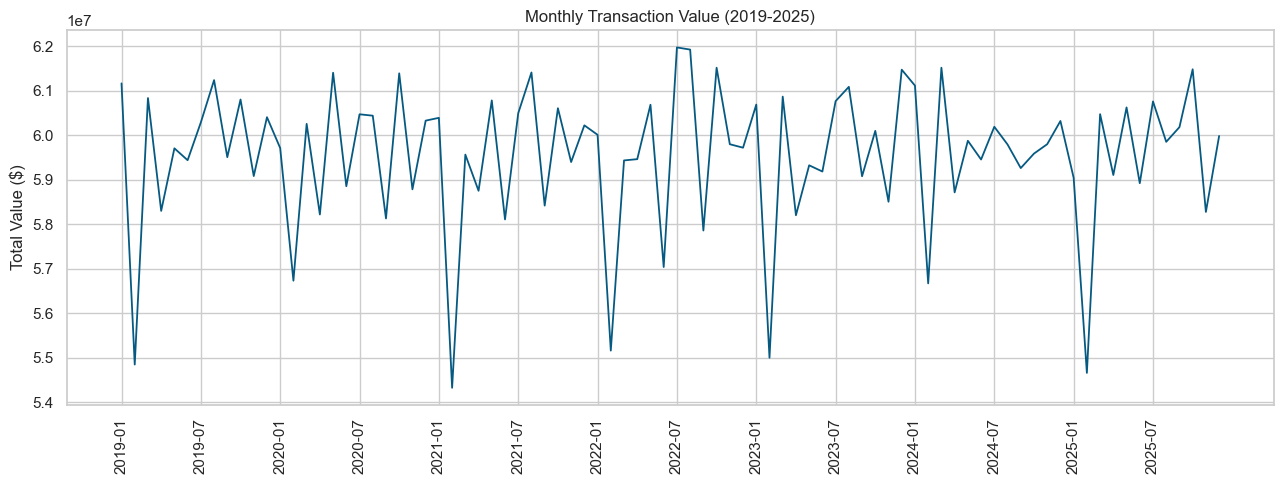

In [22]:
monthly = pd.read_sql(
    "SELECT strftime('%Y-%m', transaction_date) AS month, COUNT(*) AS num_txns, "
    "SUM(amount_usd) AS total_value FROM transactions GROUP BY month ORDER BY month", con)

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(monthly['month'], monthly['total_value'], color='#065A82', linewidth=1.3)
ax.set_title('Monthly Transaction Value (2019-2025)')
ax.set_ylabel('Total Value ($)')
ax.set_xticks(ax.get_xticks()[::6])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

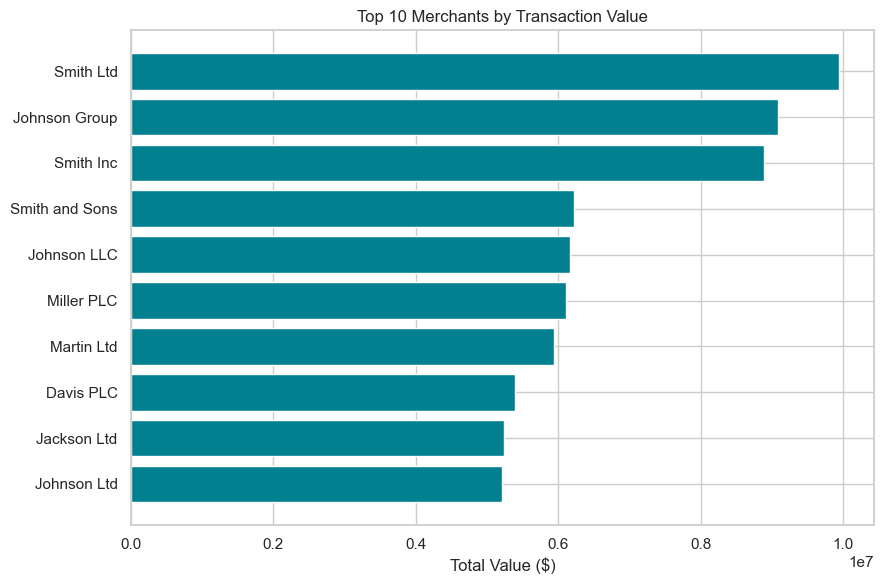

,merchant_name,num_txns,total_value
0,Smith Ltd,1985,"9,934,738.56"
1,Johnson Group,1792,"9,086,620.40"
2,Smith Inc,1774,"8,884,417.07"
3,Smith and Sons,1228,"6,224,328.87"
4,Johnson LLC,1192,"6,158,857.98"
5,Miller PLC,1224,"6,112,326.12"
6,Martin Ltd,1199,"5,935,659.34"
7,Davis PLC,1040,"5,395,530.01"
8,Jackson Ltd,1016,"5,243,459.48"
9,Johnson Ltd,1040,"5,212,420.79"


In [23]:
top_merchants = pd.read_sql(
    "SELECT m.merchant_name, COUNT(*) AS num_txns, ROUND(SUM(t.amount_usd),2) AS total_value "
    "FROM transactions t JOIN merchants m ON t.merchant_id = m.merchant_id "
    "GROUP BY m.merchant_name ORDER BY total_value DESC LIMIT 10", con)

fig, ax = plt.subplots(figsize=(9,6))
ax.barh(top_merchants['merchant_name'][::-1], top_merchants['total_value'][::-1], color='#028090')
ax.set_title('Top 10 Merchants by Transaction Value')
ax.set_xlabel('Total Value ($)')
plt.tight_layout()
plt.show()
top_merchants

**Finding:** Monthly transaction volume is remarkably stable (~$55–62M/month) with a consistent dip every February (fewer calendar days, not a real seasonal effect). This regularity, like the credit score distribution, is a signature of synthetic data generation rather than organic customer behavior.

## 4. Does Credit Score Predict Loan Interest Rate?

In a real bank, lower credit scores should mean higher interest rates (higher risk premium). We test whether that relationship holds here.

,credit_band,num_loans,avg_interest_rate
0,1-Poor,15221,8.54
1,2-Fair,4917,8.57
2,3-Good,3865,8.55
3,4-Very Good,3240,8.47
4,5-Excellent,2757,8.57


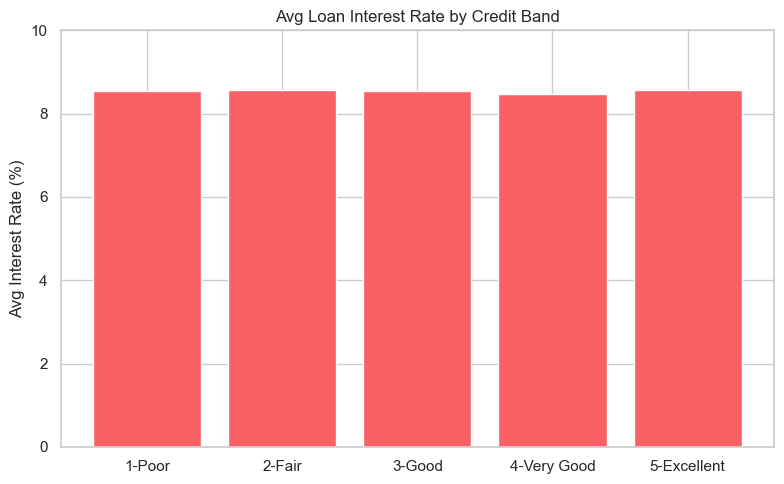

In [24]:
credit_interest = pd.read_sql(
    "SELECT CASE "
    "WHEN c.credit_score < 580 THEN '1-Poor' "
    "WHEN c.credit_score < 670 THEN '2-Fair' "
    "WHEN c.credit_score < 740 THEN '3-Good' "
    "WHEN c.credit_score < 800 THEN '4-Very Good' "
    "ELSE '5-Excellent' END AS credit_band, "
    "COUNT(*) AS num_loans, ROUND(AVG(l.interest_rate),3) AS avg_interest_rate "
    "FROM loans l JOIN customers c ON l.customer_id = c.customer_id "
    "GROUP BY credit_band ORDER BY credit_band", con)
display(credit_interest)

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(credit_interest['credit_band'], credit_interest['avg_interest_rate'], color='#F96167')
ax.set_ylim(0, 10)
ax.set_title('Avg Loan Interest Rate by Credit Band')
ax.set_ylabel('Avg Interest Rate (%)')
plt.tight_layout()
plt.show()

**Finding:** Average interest rate is essentially flat across every credit band (8.47%–8.57%, a spread of just 0.1 points). In real underwriting this spread would typically span several percentage points. This tells us interest rates in this dataset were assigned independently of credit score — an important caveat: **any pricing model built on this relationship in this dataset would not generalize to real lending data.**

## 5. Customer Segmentation (Credit Risk + Debt Burden)

We combine credit score and debt-to-balance ratio into four practical segments a bank could use for targeting and risk monitoring.

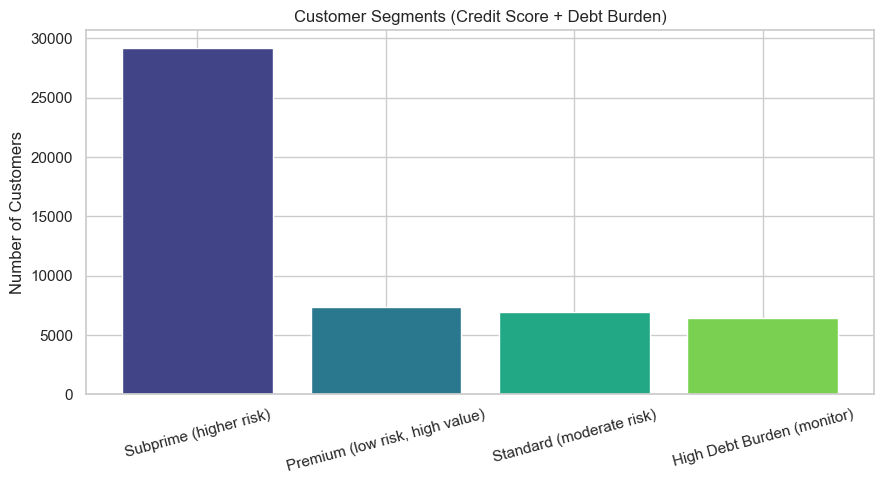

segment
Subprime (higher risk)            29219
Premium (low risk, high value)     7398
Standard (moderate risk)           6984
High Debt Burden (monitor)         6399
Name: count, dtype: int64

                                credit_score  total_balance  total_loans
segment                                                                 
High Debt Burden (monitor)            574.00      96,265.00   286,824.00
Premium (low risk, high value)        795.00     145,643.00    36,162.00
Standard (moderate risk)              722.00     169,277.00    87,729.00
Subprime (higher risk)                485.00     158,063.00    61,518.00


In [25]:
cust_seg = pd.read_sql(
    "SELECT c.customer_id, c.credit_score, "
    "COALESCE(a.total_balance, 0) AS total_balance, "
    "COALESCE(l.total_loans, 0) AS total_loans "
    "FROM customers c "
    "LEFT JOIN (SELECT customer_id, SUM(balance_usd) AS total_balance FROM accounts GROUP BY customer_id) a "
    "ON c.customer_id = a.customer_id "
    "LEFT JOIN (SELECT customer_id, SUM(loan_amount) AS total_loans FROM loans GROUP BY customer_id) l "
    "ON c.customer_id = l.customer_id", con)

cust_seg['debt_to_balance'] = (cust_seg['total_loans'] / cust_seg['total_balance'].replace(0, pd.NA)).fillna(0)

def segment(row):
    if row['credit_score'] >= 740 and row['debt_to_balance'] < 0.5:
        return 'Premium (low risk, high value)'
    elif row['credit_score'] >= 670 and row['debt_to_balance'] < 1.5:
        return 'Standard (moderate risk)'
    elif row['debt_to_balance'] >= 1.5:
        return 'High Debt Burden (monitor)'
    else:
        return 'Subprime (higher risk)'

cust_seg['segment'] = cust_seg.apply(segment, axis=1)
cust_seg.to_csv('../data/cleaned/customer_segments.csv', index=False)

seg_counts = cust_seg['segment'].value_counts()
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(seg_counts.index, seg_counts.values, color=sns.color_palette('viridis', len(seg_counts)))
ax.set_title('Customer Segments (Credit Score + Debt Burden)')
ax.set_ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(seg_counts)
print()
print(cust_seg.groupby('segment')[['credit_score','total_balance','total_loans']].mean().round(0))

**Finding:** ~58% of customers fall into "Subprime" — far higher than a real bank's book would show. This traces back to the uniform (rather than bell-curve) credit score distribution noted in Section 2. **The segmentation logic itself is sound and reusable**; the thresholds would simply need recalibrating against a real population's score distribution before deploying against actual customers.

## 6. Flagging Unusual Transactions

We first check the shape of the transaction amount distribution before choosing a method — a standard-deviation cutoff only makes sense for roughly normal data.

In [26]:
shape = pd.read_sql("SELECT MIN(amount_usd) AS min_amt, MAX(amount_usd) AS max_amt, AVG(amount_usd) AS mean_amt FROM transactions", con)
display(shape)

,min_amt,max_amt,mean_amt
0,1.02,"9,999.98","5,001.16"


Min ~$1, max ~$10,000, mean ~$5,000 (the midpoint) — this is a **uniform distribution**, not a real-world right-skewed spending pattern. A 3-sigma z-score test would flag **zero** transactions here (confirmed by testing it), because a bounded uniform distribution has no long tail. We use a **percentile-based** cutoff instead, which works regardless of distribution shape.

99.9th percentile threshold: $9,990.28
Flagged: 1,000 transactions


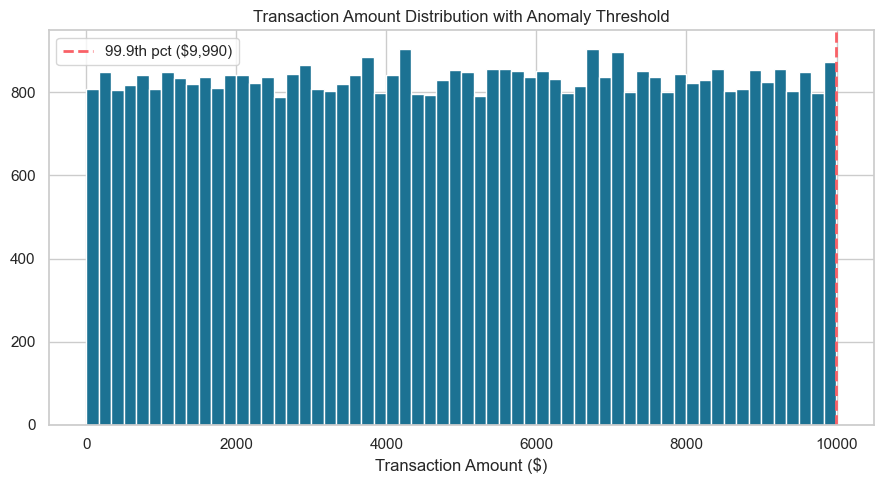

,transaction_id,account_id,amount_usd,transaction_date,merchant_name
0,TXN4DEFCFJ0ZM2AKW,ACCYWLPS5XVSQLT,"9,999.98",2022-12-30 10:52:35,"Martin, Davis and Lyons"
1,TXNPF7QD0B0L2QN6I,ACCBEY8MNZO1WBU,"9,999.98",2023-06-15 20:09:17,Fox-Serrano
2,TXNW1R6B3TAAZNUEQ,ACCCNGKH1K6OYL7,"9,999.98",2020-06-10 19:07:46,Sullivan PLC
3,TXN9V42O811E0CHSI,ACCVUNQCYL2RJ5B,"9,999.97",2019-01-29 06:17:43,"Brown, Mercer and Cox"
4,TXNSISHQT3LB54QI7,ACCRWO4KLPZXFS7,"9,999.97",2025-09-27 06:26:37,"Estes, Martin and Rogers"
5,TXNR4KUW3W899M6JR,ACC641VRH3Y5IAE,"9,999.96",2024-10-30 08:39:28,Bryant-Foster
6,TXNR10ZNWPMCRNN3K,ACCDVX9NF5NM8FZ,"9,999.93",2021-05-27 08:24:39,"Marshall, Byrd and Friedman"
7,TXNT7YLJP7I9LPOT9,ACC0AW4WFZC3QGL,"9,999.93",2023-02-22 00:53:59,Ford-Davis
8,TXN3ZR2R9PSUKU2PF,ACC2AY4QKO7ZWHA,"9,999.91",2024-07-21 06:12:27,"James, Jones and Harrison"
9,TXN6FAWV0K9AIP3BZ,ACCBNJNLJSUJ55N,"9,999.91",2020-10-20 02:19:19,Burke-Walters


In [27]:
pctl = pd.read_sql("SELECT amount_usd FROM transactions", con)
p999 = pctl['amount_usd'].quantile(0.999)
print(f"99.9th percentile threshold: ${p999:,.2f}")

flagged = pd.read_sql(
    "SELECT t.transaction_id, t.account_id, t.amount_usd, t.transaction_date, m.merchant_name "
    "FROM transactions t JOIN merchants m ON t.merchant_id = m.merchant_id "
    f"WHERE t.amount_usd > {p999} ORDER BY t.amount_usd DESC", con)

flagged.to_csv('../data/cleaned/flagged_transactions.csv', index=False)
print(f"Flagged: {len(flagged):,} transactions")

sample = pd.read_sql("SELECT amount_usd FROM transactions ORDER BY RANDOM() LIMIT 50000", con)
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(sample['amount_usd'], bins=60, color='#1C7293', edgecolor='white')
ax.axvline(p999, color='#F96167', linestyle='--', linewidth=2, label=f'99.9th pct (${p999:,.0f})')
ax.set_title('Transaction Amount Distribution with Anomaly Threshold')
ax.set_xlabel('Transaction Amount ($)')
ax.legend()
plt.tight_layout()
plt.show()

flagged.head(10)

**Finding:** 1,000 transactions (0.1%, by construction) sit above the threshold, all clustered just under the $10,000 ceiling. **Important nuance:** because the underlying distribution is uniform, these aren't behaviorally anomalous — they're simply the natural upper edge of a bounded random range. A production fraud system would instead compare each transaction against **that specific account's own historical pattern**, not a single global cutoff. Flagging that distinction matters more than the flagged list itself.

## 7. Key Findings & Recommendations

| # | Finding | Recommendation |
|---|---------|-----------------|
| 1 | Data is fully clean — zero nulls, dupes, or broken foreign keys | N/A — confirms dataset is analysis-ready |
| 2 | Account balances are nearly identical across Checking/Savings/Business | Account type alone isn't a useful segmentation axis |
| 3 | Credit score has almost no relationship with loan interest rate | Any pricing model built on this data would not transfer to real underwriting |
| 4 | Credit scores and transaction amounts are uniformly (not realistically) distributed | Recalibrate segmentation thresholds against real population data before production use |
| 5 | Global percentile-based flagging surfaces only the top of a bounded range, not true anomalies | Real fraud detection needs per-account behavioral baselines, not one global cutoff |

## Next Steps
- Re-run segmentation thresholds against a realistically-distributed credit score population
- Build per-account rolling-average anomaly detection instead of a global percentile cutoff
- Explore whether `branches` could be meaningfully linked to accounts in a future data version

---
*Data source: Synthetic banking dataset (Kaggle), 2019–2025.*